# 04 Baseline Model Training

This notebook trains the first baseline classification models for the Bank Marketing project.

The goal is to establish a simple and reproducible baseline before exploring more advanced models and hyperparameter tuning.

## Evaluation Strategy

The focus is evaluation first:

- Define the evaluation metrics before comparing models.
- Use the same evaluation procedure for every model.
- Progress from simpler models to more complex ones.
- Leave hyperparameter tuning for a later notebook.

## Modeling Scope

Three model classes are trained with increasing complexity:

1. Logistic Regression – linear baseline.
2. Decision Tree – interpretable non-linear model.
3. XGBoost – gradient boosting model for tabular data.

## 1. Setup

In [1]:
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    brier_score_loss,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import StratifiedKFold, learning_curve
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 120)

RANDOM_STATE = 42


def find_project_root(start: Path) -> Path:
    for path in [start, *start.parents]:
        if (path / "data" / "processed" / "X_train_processed.csv").exists():
            return path
    raise FileNotFoundError("Could not find project root with processed training data.")


PROJECT_ROOT = find_project_root(Path.cwd())
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
MODELS_DIR = PROJECT_ROOT / "models"
MODEL_RESULTS_DIR = PROJECT_ROOT / "reports" / "model_results"

print(f"Project root: {PROJECT_ROOT}")
print(f"Processed data directory: {PROCESSED_DIR}")
print(f"Model results directory: {MODEL_RESULTS_DIR}")

Project root: /home/patri/master/ads2-bank-marketing-project
Processed data directory: /home/patri/master/ads2-bank-marketing-project/data/processed
Model results directory: /home/patri/master/ads2-bank-marketing-project/reports/model_results


## Scikit-learn (sklearn)

Scikit-learn (sklearn) es una de las librerías de Machine Learning más utilizadas en Python.

Contiene implementaciones ya preparadas de algoritmos y herramientas de ML, por lo que no es necesario programarlas desde cero.

Algunos ejemplos:

- LogisticRegression → modelo de clasificación.
- DecisionTreeClassifier → árbol de decisión.
- StandardScaler → escalado de variables numéricas.
- OneHotEncoder → codificación de variables categóricas.
- SimpleImputer → imputación de valores faltantes.
- train_test_split → división Train/Test.
- Pipeline → encadena varios pasos de preprocesamiento.
- ColumnTransformer → aplica transformaciones distintas según el tipo de columna.
- accuracy_score, precision_score, recall_score, f1_score → métricas para evaluar modelos.

En resumen, sklearn es la librería principal para construir, entrenar y evaluar modelos de Machine Learning en Python.

## 2. Load Processed Data

In [ ]:
X_train = pd.read_csv(PROCESSED_DIR / "X_train_processed.csv")
X_test = pd.read_csv(PROCESSED_DIR / "X_test_processed.csv")
y_train = pd.read_csv(PROCESSED_DIR / "y_train.csv")["y_binary"]
y_test = pd.read_csv(PROCESSED_DIR / "y_test.csv")["y_binary"]
feature_names = pd.read_csv(PROCESSED_DIR / "feature_names.csv")["feature_name"].tolist()
test_metadata = pd.read_csv(PROCESSED_DIR / "test_metadata.csv")

print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test:  {y_test.shape}")
print(f"Features: {len(feature_names)}")
print(f"Test metadata: {test_metadata.shape}")

X_train: (36168, 56)
X_test:  (9043, 56)
y_train: (36168,)
y_test:  (9043,)
Features: 56
Test metadata: (9043, 19)


In [8]:
pd.DataFrame({
    "train_percent": y_train.value_counts(normalize=True).mul(100).round(2),
    "test_percent": y_test.value_counts(normalize=True).mul(100).round(2),
})

,train_percent,test_percent
y_binary,,
0,88.3,88.3
1,11.7,11.7


## 3. Evaluation-First Function

The same evaluation function is used for every model to ensure a fair comparison.

It calculates classification metrics, probability-based metrics, the confusion matrix, and the difference between training and test performance.

Business-value simulation is not included at this stage because reliable campaign cost and revenue assumptions are not available.

#### Evaluation Metrics

- **Accuracy:** Percentage of total predictions that the model classified correctly.
- **Precision:** Of all customers predicted as positive, how many were actually positive.
- **Recall:** Of all customers who were actually positive, how many the model correctly identified.
- **F1 Score:** Harmonic mean of precision and recall, providing a balance between both metrics.
- **ROC-AUC:** Measures the model's ability to rank positive cases higher than negative cases across different classification thresholds.
- **Brier Score:** Measures the accuracy of predicted probabilities. Lower values indicate better probability predictions.
- **Generalization Gap:** Difference between training and test performance. A large gap may indicate overfitting.

In [8]:
def evaluate_model(
    model,
    model_name: str,
    X_train: pd.DataFrame,
    y_train: pd.Series,
    X_test: pd.DataFrame,
    y_test: pd.Series,
    threshold: float = 0.5,
) -> dict:
    """Evaluate a fitted binary classification model."""

    # Predictions for the training set.
    y_train_pred = model.predict(X_train)

    # Use prediction probabilities when the model supports them.
    if hasattr(model, "predict_proba"):
        y_test_score = model.predict_proba(X_test)[:, 1]
        y_test_pred = (y_test_score >= threshold).astype(int)

        roc_auc = roc_auc_score(y_test, y_test_score)
        brier_score = brier_score_loss(y_test, y_test_score)
    else:
        y_test_score = None
        y_test_pred = model.predict(X_test)

        roc_auc = None
        brier_score = None

    report = classification_report(
        y_test,
        y_test_pred,
        output_dict=True,
        zero_division=0,
    )

    train_f1 = f1_score(
        y_train,
        y_train_pred,
        zero_division=0,
    )

    test_f1 = f1_score(
        y_test,
        y_test_pred,
        zero_division=0,
    )

    return {
        "model_name": model_name,
        "threshold": threshold,
        "accuracy": accuracy_score(y_test, y_test_pred),
        "precision": precision_score(
            y_test,
            y_test_pred,
            zero_division=0,
        ),
        "recall": recall_score(
            y_test,
            y_test_pred,
            zero_division=0,
        ),
        "f1": test_f1,
        "roc_auc": roc_auc,
        "brier_score": brier_score,
        "train_f1": train_f1,
        "test_f1": test_f1,
        "generalization_gap": train_f1 - test_f1,
        "confusion_matrix": confusion_matrix(
            y_test,
            y_test_pred,
            labels=[0, 1],
        ),
        "classification_report": report,
        "y_pred": y_test_pred,
        "y_score": y_test_score,
    }

## 4. Train Models from Simple to More Complex

In [10]:
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=RANDOM_STATE,
    ),
    "Decision Tree": DecisionTreeClassifier(
        random_state=RANDOM_STATE,
    ),
    "XGBoost": XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
}

results = {}

for model_name, model in models.items():
    model.fit(X_train, y_train)

    results[model_name] = evaluate_model(
        model=model,
        model_name=model_name,
        X_train=X_train,
        y_train=y_train,
        X_test=X_test,
        y_test=y_test,
        threshold=0.5,
    )

print("Finished training and evaluation.")

Finished training and evaluation.


## 5. Compare Model Metrics

In [13]:
metric_columns = [
    "model_name",
    "accuracy",
    "precision",
    "recall",
    "f1",
    "roc_auc",
    "brier_score",
    "train_f1",
    "test_f1",
    "generalization_gap",
]

metrics_df = pd.DataFrame([
    {column: result[column] for column in metric_columns}
    for result in results.values()
])

metrics_df.sort_values("f1", ascending=False).round(4)

,model_name,accuracy,precision,recall,f1,roc_auc,brier_score,train_f1,test_f1,generalization_gap
2,XGBoost,0.8934,0.5983,0.2703,0.3724,0.7910,0.0832,0.5878,0.3724,0.2154
1,Decision Tree,0.8317,0.2993,0.3270,0.3126,0.6128,0.1683,1.0000,0.3126,0.6874
0,Logistic Regression,0.8926,0.6548,0.1739,0.2748,0.7742,0.0850,0.2792,0.2748,0.0044


Interpretation guide:

- `f1` balances precision and recall.
- `recall` tells us how many actual churn customers we identify.
- `precision` tells us how many predicted churn customers are truly churn customers.
- `generalization_gap` compares train and test F1. A large gap can indicate high variance or overfitting.
- `brier_score` evaluates probability quality. Lower values are better. This matters when probabilities drive business decisions.

##### Key Observations

- Logistic Regression shows the smallest generalization gap, suggesting stable performance between training and test data.
- XGBoost achieves the highest F1 score and ROC-AUC among the three baseline models.
- The Decision Tree shows a large generalization gap, indicating strong overfitting.
- Overall accuracy is relatively high for all models, but recall remains low, showing that many positive cases are still missed.

## 6. Save Evaluation Results

The evaluation outputs are saved as CSV files so they can be reused in later notebooks.

Saved artifacts:

- model comparison metrics;
- row-level predictions;
- predicted subscription probabilities;
- original test metadata for traceability and error analysis.

In [15]:
MODEL_RESULTS_DIR.mkdir(parents=True, exist_ok=True)

baseline_metrics_path = (MODEL_RESULTS_DIR / "04_baseline_model_metrics.csv")
baseline_predictions_path = (MODEL_RESULTS_DIR / "04_baseline_predictions.csv")

# Save the model comparison table.
metrics_df.to_csv(baseline_metrics_path,index=False,)

# Save row-level predictions for each model.
prediction_rows = []

for model_name, result in results.items():
    model_predictions = test_metadata.copy()
    model_predictions.insert(0,"model_name",model_name,)

    model_predictions["y_true"] = y_test.to_numpy()
    model_predictions["y_pred"] = result["y_pred"]
    model_predictions["subscription_probability"] = result["y_score"]

    prediction_rows.append(model_predictions)

baseline_predictions_df = pd.concat(prediction_rows,ignore_index=True,)
baseline_predictions_df.to_csv(baseline_predictions_path,index=False,)

print(f"Saved metrics to: {baseline_metrics_path}")
print(f"Saved predictions to: {baseline_predictions_path}")

Saved metrics to: /home/patri/master/ads2-bank-marketing-project/reports/model_results/04_baseline_model_metrics.csv
Saved predictions to: /home/patri/master/ads2-bank-marketing-project/reports/model_results/04_baseline_predictions.csv


## 7. Confusion Matrices

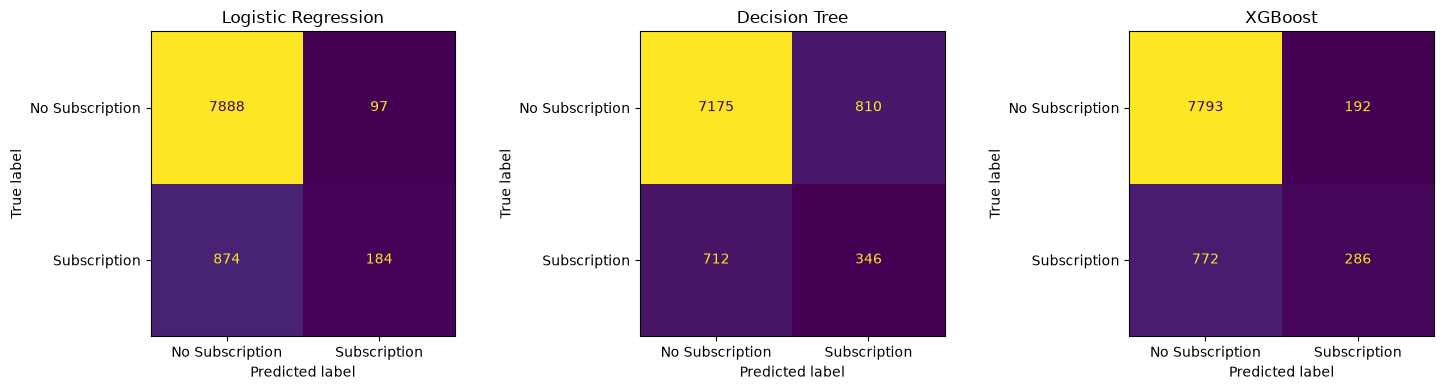

In [16]:
fig, axes = plt.subplots(1, len(results), figsize=(15, 4))

for ax, (model_name, result) in zip(axes, results.items()):
    ConfusionMatrixDisplay(
        confusion_matrix=result["confusion_matrix"],
        display_labels=["No Subscription", "Subscription"]
    ).plot(ax=ax, colorbar=False)
    ax.set_title(model_name)

plt.tight_layout()
plt.show()

#### Interpretation

The confusion matrices show the types of correct and incorrect predictions made by each model.

- **True Negative (TN):** the customer did not subscribe and the model correctly predicted no subscription.
- **False Positive (FP):** the customer did not subscribe, but the model predicted subscription.
- **False Negative (FN):** the customer subscribed, but the model failed to identify the positive case.
- **True Positive (TP):** the customer subscribed and the model correctly identified the positive case.

False negatives represent potential subscribers that the model fails to identify, while false positives represent customers incorrectly classified as likely subscribers.

#### Key Observations

- Logistic Regression produces very few false positives but misses a large number of actual subscribers.
- Decision Tree identifies more subscribers but generates substantially more false positives and shows strong overfitting.
- XGBoost provides a better balance between identifying subscribers and limiting false positives.
- All three models still produce a high number of false negatives, consistent with the relatively low recall observed in the model comparison.

## 8. Bias-Variance Reflection

In [17]:
bias_variance_df = metrics_df[
    ["model_name", "train_f1", "test_f1", "generalization_gap"]
].sort_values("generalization_gap", ascending=False)

bias_variance_df.round(4)

,model_name,train_f1,test_f1,generalization_gap
1,Decision Tree,1.0000,0.3126,0.6874
2,XGBoost,0.5878,0.3724,0.2154
0,Logistic Regression,0.2792,0.2748,0.0044


A high training score with a much lower validation score can indicate overfitting and high variance.

Typical expectations:

- Logistic Regression is often more biased but more stable.
- A single Decision Tree can overfit strongly.
- XGBoost may reduce variance compared with a single tree, although it can still overfit.

These are tendencies, not guarantees. The data and model settings still matter.

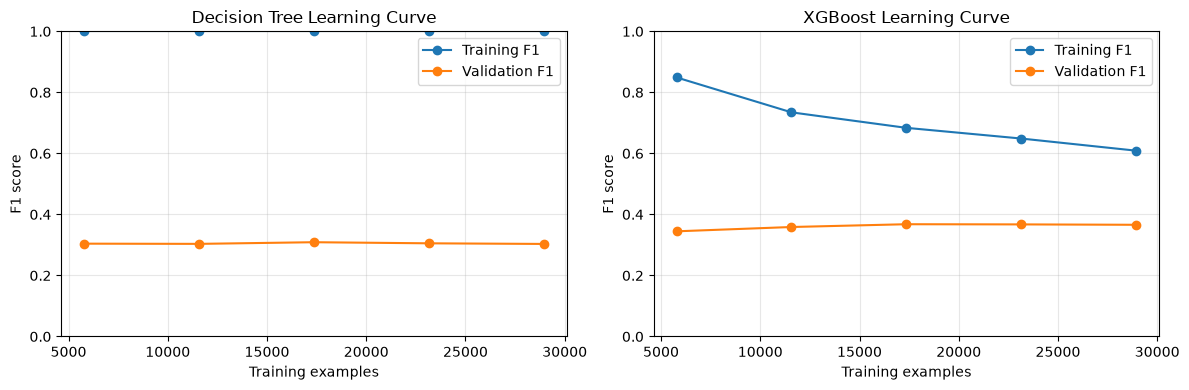

In [18]:
def plot_learning_curve_for_model(model, model_name: str) -> None:
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

    train_sizes, train_scores, validation_scores = learning_curve(
        estimator=model,
        X=X_train,
        y=y_train,
        train_sizes=[0.2, 0.4, 0.6, 0.8, 1.0],
        cv=cv,
        scoring="f1",
        n_jobs=-1,
    )

    train_mean = train_scores.mean(axis=1)
    validation_mean = validation_scores.mean(axis=1)

    plt.plot(train_sizes, train_mean, marker="o", label="Training F1")
    plt.plot(train_sizes, validation_mean, marker="o", label="Validation F1")
    plt.title(model_name)
    plt.xlabel("Training examples")
    plt.ylabel("F1 score")
    plt.ylim(0, 1)
    plt.legend()
    plt.grid(True, alpha=0.3)


plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plot_learning_curve_for_model(
    DecisionTreeClassifier(random_state=RANDOM_STATE),
    "Decision Tree Learning Curve",
)

plt.subplot(1, 2, 2)
plot_learning_curve_for_model(
    XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
    "XGBoost Learning Curve",
)

plt.tight_layout()
plt.show()

##### Key Observations
- The Decision Tree shows strong overfitting: training F1 remains close to 1.0 while validation F1 stays around 0.30.
- XGBoost also shows overfitting, but the gap between training and validation F1 decreases as the training set grows.
- Compared with the Decision Tree, XGBoost shows better generalization behavior, although there is still room for improvement through hyperparameter tuning.

## 9. Save Best Baseline Model

In [19]:
from datetime import datetime


def safe_model_name(name: str) -> str:
    return "".join(ch if ch.isalnum() else "_" for ch in name).strip("_")


best_model_name = metrics_df.sort_values("f1", ascending=False).iloc[0]["model_name"]
best_model = models[best_model_name]
model_class_name = best_model.__class__.__name__
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

MODELS_DIR.mkdir(parents=True, exist_ok=True)
model_path = MODELS_DIR / f"{timestamp}_{safe_model_name(model_class_name)}_baseline_model.joblib"
joblib.dump(best_model, model_path)

print(f"Best baseline model by F1: {best_model_name}")
print(f"Model class: {model_class_name}")
print(f"Saved model to: {model_path}")

Best baseline model by F1: XGBoost
Model class: XGBClassifier
Saved model to: /home/patri/master/ads2-bank-marketing-project/models/20260717_165348_XGBClassifier_baseline_model.joblib


### Save Best Baseline Model

The model with the highest test F1 score is selected automatically.

The fitted model is saved as a `.joblib` file so it can be reused without retraining. A timestamp is included to support model versioning.

## 10. Experiment Management Log

In team settings, model development should not live only inside individual notebooks. A simple shared sheet can already make work transparent:

- Which experiment was run?
- Who was responsible?
- What hypothesis was tested?
- Which data and features were used?
- What were the key model and business results?
- What is the next decision?

This follows the same principle as the central experimentation log example: use one shared place to document PoC, prototype, and production-oriented experimentation.

For this demo project, the manually maintained experiment log is here:

[reports/experiment_log.xlsx](../reports/experiment_log.xlsx)

It is intentionally treated as a team artifact that is maintained outside the code flow. MLflow will later automate parts of this process, but the underlying discipline is the same.

## 11. Baseline Training Summary

This notebook established an evaluation-first baseline workflow:

- The same evaluation function was used for all models.
- Logistic Regression, Decision Tree, and XGBoost were trained and compared.
- Model performance was evaluated using classification and probability-based metrics.
- Confusion matrices were used to inspect prediction errors.
- Bias and variance were analysed using generalization gaps and learning curves.
- XGBoost achieved the highest baseline F1 score and ROC-AUC.
- The best baseline model was saved for later reuse.

The next notebook will tune XGBoost hyperparameters and evaluate whether optimization improves test performance and generalization.